# WFE estimates for different data sets

In [104]:
import os
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import re
from plotting import set_dark_transparent

In [105]:
results_path = 'results/observation_window_sweep_BIG'
folder_names = [f for f in os.listdir(results_path) if os.path.isdir(os.path.join(results_path, f))]

In [106]:
path = folder_names[2]
data = np.load(f'{results_path}/{path}/observation_precision_data.npz')
print(path)
print("keys")
print(list(data.keys()))

length_list = []

set_diam = [10,100,1000]

#for key in data:
    #print(f"{key}: shape={data[key].shape}, dtype={data[key].dtype}")
    #print(data[key])
    #print("="*30)
    

for path in tqdm(folder_names):
    length = int(re.search(r'sim_(\d+)_(\d+)', path).group(2))
    length_list.append(length)
    
print(length_list)

sim_1000_75
keys
['time_rel_sec', 'error_star_m', 'phase']


100%|██████████| 18/18 [00:00<00:00, 39057.15it/s]

[210, 45, 75, 105, 135, 195, 150, 180, 120, 60, 240, 15, 225, 270, 165, 255, 30, 90]


/var/folders/dr/hkg8_lxd1vz_gt1xrn83pg9h0000gn/T/ipykernel_29263/1820338477.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', len(values))


['sim_1000_270', 'sim_1000_255', 'sim_1000_240', 'sim_1000_225', 'sim_1000_210', 'sim_1000_195', 'sim_1000_180', 'sim_1000_165', 'sim_1000_150', 'sim_1000_135', 'sim_1000_120', 'sim_1000_105', 'sim_1000_90', 'sim_1000_75', 'sim_1000_60', 'sim_1000_45', 'sim_1000_30', 'sim_1000_15']


100%|██████████| 18/18 [00:00<00:00, 87.54it/s]


[np.float64(269.90000000000146), np.float64(254.90000000000146), np.float64(239.90000000000146), np.float64(224.90000000000146), np.float64(209.90000000000146), np.float64(194.90000000000146), np.float64(179.90000000000146), np.float64(164.90000000000146), np.float64(149.90000000000146), np.float64(134.90000000000146), np.float64(119.90000000000146), np.float64(104.90000000000146), np.float64(89.90000000000146), np.float64(74.90000000000146), np.float64(59.900000000001455), np.float64(44.900000000001455), np.float64(29.900000000001455), np.float64(14.900000000001455)]


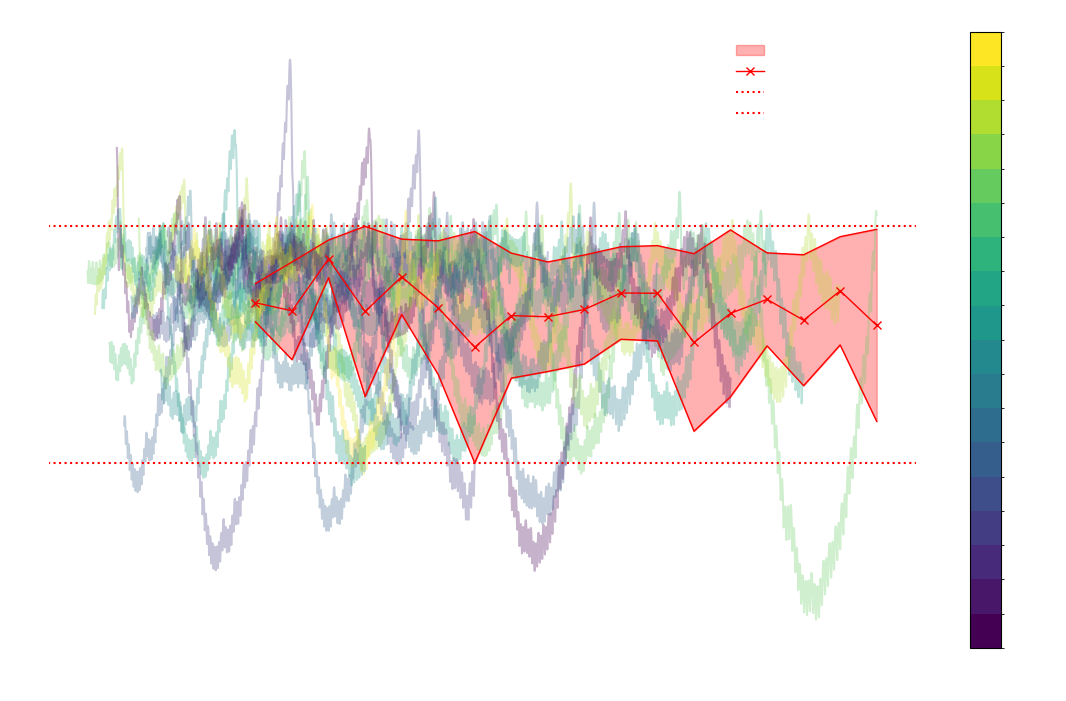

plots counted: 18


In [107]:
plt.figure(figsize=(14,8))

values = length_list
cmap = cm.get_cmap('viridis', len(values))

sorted_folders = sorted(folder_names, key=lambda x: int(x.split('_')[2]), reverse=True)

print(sorted_folders)

error_mean = []
error_std = []
error_time = []

overwrite = False

# path overwrites
if overwrite:
    path = []
    for window in [30, 60, 90]:
        path.append(f'sim_100_{window}')

count=0

# Map each value to its discrete color by index
value_to_color = {v: cmap(i / (len(values) - 1)) for i, v in enumerate(values)}

for path in tqdm(sorted_folders):
    data = np.load(f'{results_path}/{path}/observation_precision_data.npz')
    diam = int(re.search(r'sim_(\d+)_(\d+)', path).group(1))
    if diam in set_diam:
        length = int(re.search(r'sim_(\d+)_(\d+)', path).group(2))

        time = data['time_rel_sec']
        error = data['error_star_m'][:,2] * 1e6
        #error = np.sum(data['error_star_m'] * 1e6, axis=1)
        plt.plot(time, error, alpha=0.3, color=value_to_color.get(length, 'white'))
        idx = np.argmin(np.abs(time - length / 2))
        error_mean.append(np.mean(error))
        error_time.append(time[-1])
        error_std.append(np.std(error))
        #plt.scatter(time[idx], error[idx, 2], color="red", marker='x') 

    count += 1

print(error_time)

#plt.scatter(error_time, error_middle, color='red', label='middle of observation')
plt.title(f"Formation Flight Defocus Errors for {diam} m wide Aperture")
plt.ylabel("z-WFE [µm]")
plt.xlabel("observation time [s]")

error_time = np.array(error_time)
error_mean = np.array(error_mean)
error_std = np.array(error_std)

# STD PLOT
std_upper = error_mean+error_std
std_lower = error_mean-error_std
plt.fill_between(error_time, std_lower, std_upper, color='red', alpha=0.3, label=f'±σ' )


# Colorbar with correct discrete tick labels
bounds = np.arange(-0.5, len(values), 1)
norm = mcolors.BoundaryNorm(bounds, cmap.N)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), ticks=np.arange(len(values)))
cbar.set_ticklabels(values, color='white')

# mean error plots
plt.plot(error_time, error_mean, marker='x', color='red', linewidth =1, label=f'mean error')
plt.plot(error_time, std_lower, linestyle='-', color='red', linewidth =1)
plt.plot(error_time, std_upper, linestyle='-', color='red', linewidth =1)

plt.axhline(np.max(std_upper), label='STD upper bounds', color='red', linestyle=":")
plt.axhline(np.min(std_lower), label='STD lower bounds', color='red', linestyle=":")

plt.legend()


# make transparent
set_dark_transparent()

# Make colorbar text white to match transparent dark theme
cbar.ax.yaxis.set_tick_params(color='white')
cbar.ax.tick_params(colors='white')
cbar.set_label('Observation Time (s)', color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

plt.show()


print(f'plots counted: {count}')

  0%|          | 0/18 [00:00<?, ?it/s]

100%|██████████| 18/18 [00:00<00:00, 144.95it/s]


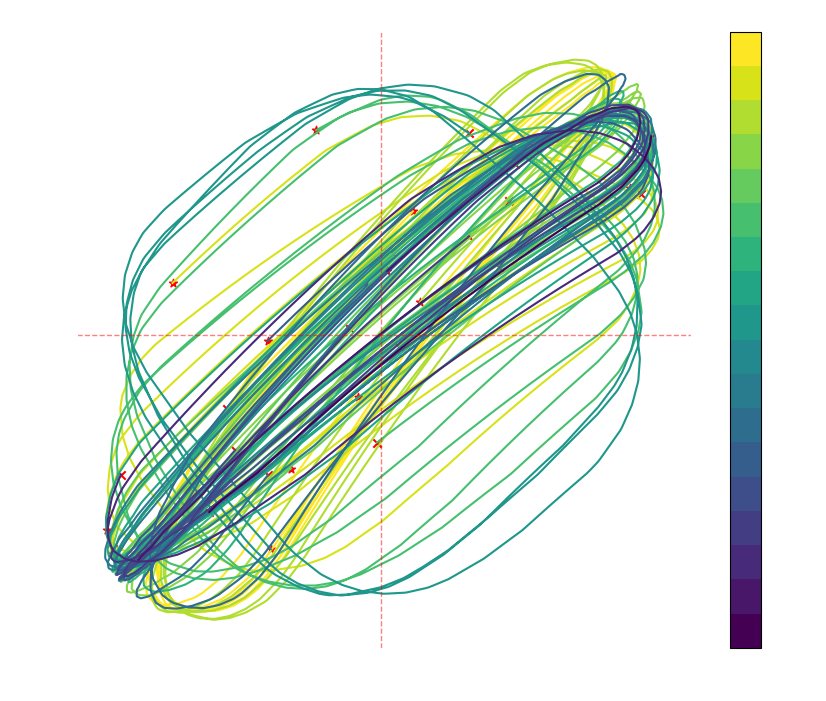

In [108]:
plt.figure(figsize=(10, 8))
error_mean_x = []
error_mean_y = []
error_std = []
error_time = []
# 1. Get the colormap and setup the normalizer based on our values
cmap = plt.get_cmap('viridis', len(values))
norm = mcolors.Normalize(vmin=min(values), vmax=max(values))
for path in tqdm(sorted_folders):
    data = np.load(f'{results_path}/{path}/observation_precision_data.npz')
    diam = int(re.search(r'sim_(\d+)_(\d+)', path).group(1))
    if diam in set_diam:
        length = int(re.search(r'sim_(\d+)_(\d+)', path).group(2))
        time = data['time_rel_sec']
        error = data['error_star_m'][:,:2] * 1e6
        
        # 2. Use the normalizer to pick the correct color for the plot line
        scatter = plt.plot(error[:,0], error[:,1], color=cmap(norm(length)))
        plt.scatter(error[0,0], error[0,1], color='red', marker='x', label='start')
        plt.scatter(error[-1,0], error[-1,1], color='red', marker='*', label='end')
        
        idx = np.argmin(np.abs(time - length / 2))
        error_mean_x.append(np.mean(error[:,0]))
        error_mean_y.append(np.mean(error[:,1]))
        error_time.append(time[-1])
        error_std.append(np.std(error))
# 3. Create a ScalarMappable to link the colormap and normalizer to the colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
#plt.legend()
# make transparent
set_dark_transparent()
# 4. Initialize the colorbar using the ScalarMappable
cbar = plt.colorbar(sm, ax=plt.gca())
# Add the colorbar labels so we know what time each color represents
cbar.set_label('Observation Time (s)', color='white')
# Set dark theme formatting if you like
cbar.ax.yaxis.set_tick_params(color='white')
cbar.ax.tick_params(colors='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')
# Labels and title
plt.title("X vs Y Position Error over Time")
plt.xlabel("X Error [µm]")
plt.ylabel("Y Error [µm]")
# This makes the axes have an equal aspect ratio so 1um in X looks the same as 1um in Y
plt.gca().set_aspect('equal', adjustable='box')
# Add crosshairs through the zero point for reference
plt.axhline(0, color='red', linestyle='--', alpha=0.5, linewidth=1)
plt.axvline(0, color='red', linestyle='--', alpha=0.5, linewidth=1)
plt.show()

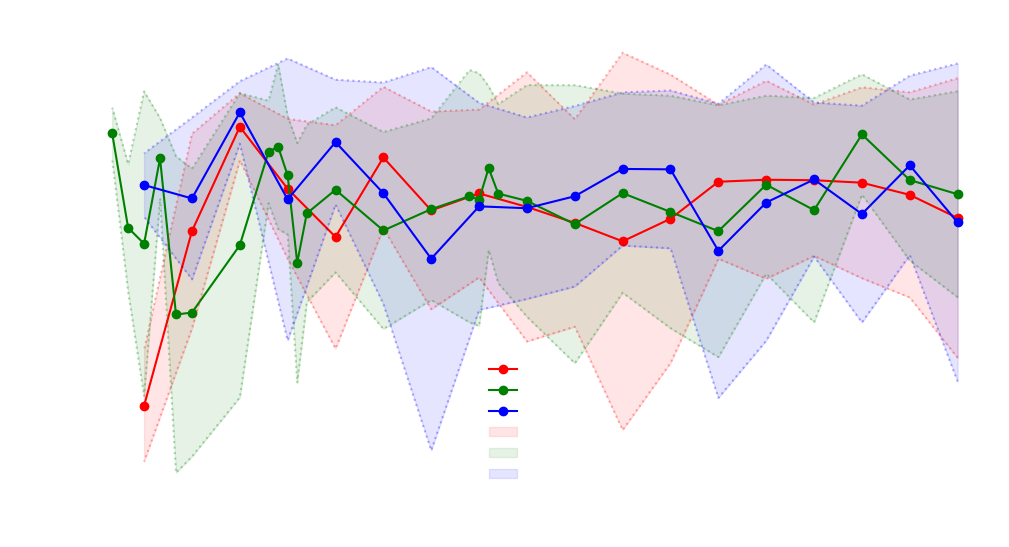

In [109]:
path_list = ['results/observation_window_sweep', 'results/observation_window_sweep_BIG', 'results/observation_window_sweep_SMALLER']
set_diam = [10,100,1000]

error_mean_10, error_std_10, error_time_10 = [], [], []
error_mean_100, error_std_100, error_time_100 = [], [], []
error_mean_1000, error_std_1000, error_time_1000 = [], [], []

for results_path in path_list:
    folder_names = [
        f for f in os.listdir(results_path)
        if os.path.isdir(os.path.join(results_path, f))
    ]
    sorted_folders = sorted(
        folder_names,
        key=lambda x: int(x.split('_')[2]),
        reverse=True
    )
    for folder in sorted_folders:
        file_path = os.path.join(
            results_path,
            folder,
            "observation_precision_data.npz"
        )
        if not os.path.isfile(file_path):
            continue
        data = np.load(file_path)
        match = re.search(r'sim_(\d+)_(\d+)', folder)
        if not match:
            continue
        diam = int(match.group(1))
        time = data['time_rel_sec']
        error = data['error_star_m'][:, 2] * 1e6
        mean = np.mean(error)
        std = np.std(error)
        final_time = time[-1]
        if diam == 10:
            error_mean_10.append(mean)
            error_std_10.append(std)
            error_time_10.append(final_time)
        elif diam == 100:
            error_mean_100.append(mean)
            error_std_100.append(std)
            error_time_100.append(final_time)
        elif diam == 1000:
            error_mean_1000.append(mean)
            error_std_1000.append(std)
            error_time_1000.append(final_time)

plt.figure(figsize=(12,6))


plt.plot(error_time_10, error_mean_10, label='10 m', color='red', marker='o')
plt.plot(error_time_100, error_mean_100, label='100 m', color='green', marker='o')
plt.plot(error_time_1000, error_mean_1000, label='1000 m', color='blue', marker='o')

error_time_10 = np.array(error_time_10)
error_mean_10 = np.array(error_mean_10)
error_std_10 = np.array(error_std_10)
error_time_100 = np.array(error_time_100)
error_mean_100 = np.array(error_mean_100)
error_std_100 = np.array(error_std_100)
error_time_1000 = np.array(error_time_1000)
error_mean_1000 = np.array(error_mean_1000)
error_std_1000 = np.array(error_std_1000)

std_upper_10 = error_mean_10 + error_std_10
std_lower_10 = error_mean_10 - error_std_10
plt.fill_between(error_time_10, std_lower_10, std_upper_10, color='red', alpha=0.1, label='±σ')
plt.plot(error_time_10, std_upper_10, color='red', linestyle=':', alpha=0.3)
plt.plot(error_time_10, std_lower_10, color='red', linestyle=':', alpha=0.3)

std_upper_100 = error_mean_100 + error_std_100
std_lower_100 = error_mean_100 - error_std_100
plt.fill_between(error_time_100, std_lower_100, std_upper_100, color='green', alpha=0.1, label='±σ')
plt.plot(error_time_100, std_upper_100, color='green', linestyle=':', alpha=0.3)
plt.plot(error_time_100, std_lower_100, color='green', linestyle=':', alpha=0.3)

std_upper_1000 = error_mean_1000 + error_std_1000
std_lower_1000 = error_mean_1000 - error_std_1000
plt.fill_between(error_time_1000, std_lower_1000, std_upper_1000, color='blue', alpha=0.1, label='±σ')
plt.plot(error_time_1000, std_upper_1000, color='blue', linestyle=':', alpha=0.3)
plt.plot(error_time_1000, std_lower_1000, color='blue', linestyle=':', alpha=0.3)

plt.xlabel("observation time [s]")
plt.ylabel("defocus WFE [µm]")
plt.title("defocus performance for different aperture systems - Optical Reef")

plt.legend()

set_dark_transparent()

plt.show()

